In [1]:
import re
from collections import defaultdict
path_letencies = []
K = 3
N = 50
# for K in [3, 5, 10]:
for K in [3]:
	# filename = [f"test_data/N={N}_1/random_K={K}.txt", f"test_data/N={N}_1/1shortest_K={K}.txt"]
	filename = [f"test_data/N=50_K=3.txt", 
			 "test_data/N=50_K=3_DGRO.txt",
			 "test_data/N=50_K=3_DGRO=3.txt"
			 ]
	for i in range(3):
		with open(filename[i]) as f:
			data = f.read()
		# Regular expression to extract time and endpoint information
		pattern = re.compile(r'当前时间（毫秒精度）: (\d+), Endpoint: hostname: "(.*?)"\nport: (\d+)')

		# Dictionary to store times by endpoint
		time_by_endpoint = defaultdict(list)

		# Extract matches and organize by endpoint
		for match in pattern.finditer(data):
			time, hostname, port = match.groups()
			endpoint = f"{hostname}:{port}"
			time_by_endpoint[endpoint].append(int(time))

		# Print the results
		# for endpoint, times in time_by_endpoint.items():
		#     print(f"Endpoint: {endpoint}")
		#     print(f"Times: {times}\n")

		path_latency = []
		for endpoint, times in time_by_endpoint.items():
			path_latency.append(times[0] - time_by_endpoint['127.0.0.7:1234'][0])
		path_letencies.append(path_latency)


[0, 196, 208, 208, 390, 396, 397, 417, 424, 425, 426, 426, 431, 593, 599, 601, 601, 601, 606, 607, 611, 614, 622, 623, 630, 632, 632, 633, 639, 641, 645, 648, 794, 800, 805, 807, 808, 814, 815, 816, 821, 822, 829, 837, 839, 840, 842, 1001, 1013, 1030]
[0, 194, 196, 208, 389, 395, 396, 397, 399, 404, 424, 426, 430, 592, 598, 601, 601, 603, 605, 606, 607, 611, 615, 618, 625, 633, 633, 640, 645, 793, 798, 801, 804, 807, 813, 814, 814, 818, 820, 822, 823, 836, 840, 841, 859, 989, 1000, 1012, 1026, 1030]
[0, 193, 217, 224, 396, 398, 404, 424, 430, 431, 433, 436, 444, 603, 603, 605, 605, 615, 618, 627, 632, 635, 637, 638, 640, 643, 644, 644, 647, 652, 784, 802, 803, 805, 811, 813, 820, 821, 823, 838, 840, 840, 847, 848, 859, 863, 868, 984, 1000, 1026]


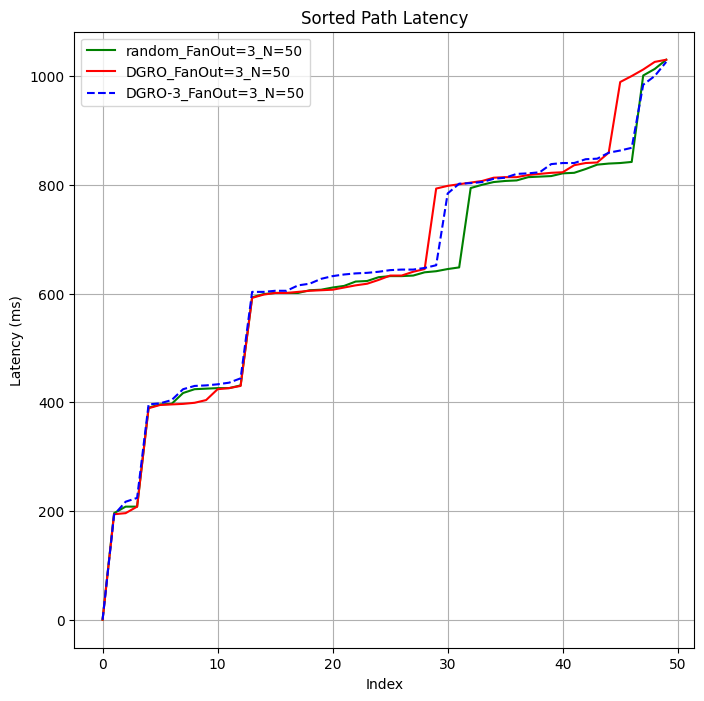

In [2]:
import matplotlib.pyplot as plt

# Plot the sorted list
fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
labels = ['random', 'DGRO', 'DGRO-3']
colors = ['g', 'r', 'b']
linestyles = ['-', '--', '-.']
cnt = 0
# for k in [3, 5, 10]:
for k in [3]:
	for i in range(3):
		
		path_latency_sorted = sorted(path_letencies[cnt])
		# print(path_latency_sorted[:5])
		print(path_latency_sorted)
		ax.plot(path_latency_sorted, linestyle=linestyles[cnt // 2], label=labels[i]+f'_FanOut={k}_N=50', color=colors[i])
		cnt += 1
ax.set_title('Sorted Path Latency')
ax.set_xlabel('Index')
ax.set_ylabel('Latency (ms)')
ax.legend()
ax.grid(True)
plt.show()
fig.savefig('2.png')

In [1]:
import re

def collect_ports(log_lines):
    """
    Collect all unique port numbers from the log lines.

    :param log_lines: List of log strings.
    :return: Set of unique ports.
    """
    port_pattern = r"\b\d+\.\d+\.\d+\.\d+:(\d+)\b"
    ports = set()

    for line in log_lines:
        match = re.findall(port_pattern, line)
        if match:
            ports.update(match)

    return ports
f = open('output.txt', 'r')
ports = collect_ports(f.readlines())
print(len(ports), ports)

38 {'1278', '1273', '1282', '1256', '1245', '1269', '1235', '1275', '1248', '1277', '1263', '1251', '1253', '1268', '1266', '1283', '1257', '1255', '1254', '1279', '1252', '1259', '1280', '1267', '1271', '1274', '1262', '1258', '1272', '1261', '1276', '1270', '1265', '1260', '1250', '1264', '1249', '1281'}


In [ ]:
import re
from collections import defaultdict

def collect_ports_with_sizes(log_lines):
    """
    Collect port numbers and their corresponding sizes from the log lines.

    :param log_lines: List of log strings.
    :return: Dictionary mapping ports to sizes.
    """
    port_size_pattern = r"port:\s*(\d+).*?expected\s*Size=(\d+)"
    port_size_map = defaultdict(int)

    for line in log_lines:
        match = re.search(port_size_pattern, line)
        if match:
            port = match.group(1)
            size = int(match.group(2))
            port_size_map[port] += size

    return dict(port_size_map)

f = open('expected_size.txt', 'r')
sizes = {}
log_context = f.readlines()
for i in range(len(log_context)):
    if 'port' in log_context[i]:
        port = log_context[i].split(' ')[-1]
        expected_size = log_context[i + 1].split('=')[-1]
        sizes[port] = int(expected_size)
# Collect port sizes
# port_sizes = collect_ports_with_sizes(log_context)
print("Port sizes:", sizes)


port: 1250

expected Size=38

port: 1261

expected Size=50

port: 1272

expected Size=38

port: 1283

expected Size=38

port: 1252

expected Size=38

port: 1263

expected Size=38

port: 1274

expected Size=38

port: 1254

expected Size=38

port: 1265

expected Size=38

port: 1276

expected Size=50

port: 1245

expected Size=38

port: 1256

expected Size=38

port: 1267

expected Size=38

port: 1278

expected Size=38

port: 1258

expected Size=38

port: 1269

expected Size=50

port: 1280

expected Size=38

port: 1249

expected Size=38

port: 1260

expected Size=38

port: 1271

expected Size=38

port: 1282

expected Size=38

port: 1251

expected Size=50

port: 1262

expected Size=38

port: 1273

expected Size=38

port: 1253

expected Size=38

port: 1264

expected Size=38

port: 1275

expected Size=38

port: 1255

expected Size=38

port: 1266

expected Size=38

port: 1277

expected Size=38

port: 1235

expected Size=38

port: 1257

expected Size=38

port: 1268

expected Size=38

port: 1279

ValueError: invalid literal for int() with base 10: 'port: 1248\n'